# NER com BiLSTM-CRF e Modelos BERT — K-Fold Cross-Validation

Adaptação do notebook original para usar **3-fold cross-validation**, garantindo que
todos os 866 documentos (229 anotados + 637 sem anotação) sejam avaliados via out-of-fold predictions.
Documentos sem anotação possuem labels all-O; se o modelo prediz entidades neles, conta como false positive.

Isso permite comparação justa com os modelos LLM que são avaliados nas mesmas 866 amostras.

**Modelos**:
1. BiLSTM-CRF
2. BERTimbau (base e large)
3. Legal-BERTimbau, Albertina, mDeBERTa

**Saída**: checkpoint `.pkl` com `{'true_labels': [...], 'pred_labels': [...]}` para
todos os 866 documentos, por modelo. Métricas logadas no W&B project `eduardoplima-imd/decicontas.br`.

In [ ]:
import wandb

wandb.login()
WANDB_PROJECT = 'decicontas.br'
WANDB_ENTITY = 'eduardoplima-imd'

import json
import gc
import re
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from tools.dataset import get_decicontas_df

SEED = 42
N_FOLDS = 3
torch.manual_seed(SEED)
np.random.seed(SEED)

CHECKPOINT_DIR = Path('dataset/results/checkpoints').resolve()
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Checkpoints: {CHECKPOINT_DIR}')

In [ ]:
import os
os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

## 2. Carregamento e Preparação dos Dados

In [ ]:
def load_decicontas():
    """Carrega o dataset decicontas via get_decicontas_df e converte para formato BIO."""
    df = get_decicontas_df()
    samples = []
    for _, row in df.iterrows():
        text = row['data']['text']
        annotations = row['annotations']
        results = []
        for ann in annotations:
            if isinstance(ann, dict) and 'result' in ann:
                results.extend(ann['result'])
            elif isinstance(ann, dict) and 'value' in ann:
                results.append(ann)
        spans = []
        for r in results:
            if 'value' in r and 'labels' in r['value']:
                val = r['value']
                spans.append({'start': val['start'], 'end': val['end'], 'label': val['labels'][0]})
        samples.append({'text': text, 'spans': spans})
    annotated = [s for s in samples if s['spans']]
    print(f'Total de amostras: {len(samples)}, Anotadas: {len(annotated)}, Sem anotação: {len(samples) - len(annotated)}')
    # Retornar TODAS as amostras — sem anotação ficam com spans=[] → labels all-O
    return samples

samples = load_decicontas()

In [ ]:
def simple_tokenize(text):
    tokens = []
    for m in re.finditer(r'\S+', text):
        tokens.append({'text': m.group(), 'start': m.start(), 'end': m.end()})
    return tokens

def spans_to_bio(tokens, spans):
    labels = ['O'] * len(tokens)
    for span in spans:
        s_start, s_end, s_label = span['start'], span['end'], span['label']
        first = True
        for i, tok in enumerate(tokens):
            if tok['start'] < s_end and tok['end'] > s_start:
                if first:
                    labels[i] = f'B-{s_label}'
                    first = False
                else:
                    labels[i] = f'I-{s_label}'
    return labels

bio_data = []
for s in samples:
    tokens = simple_tokenize(s['text'])
    labels = spans_to_bio(tokens, s['spans'])
    bio_data.append({
        'tokens': [t['text'] for t in tokens],
        'token_offsets': tokens,
        'labels': labels,
        'text': s['text'],
        'spans': s['spans']
    })

all_labels = [l for s in bio_data for l in s['labels']]
label_counts = Counter(all_labels)
print('Distribuição de tags BIO:')
for k, v in sorted(label_counts.items()):
    print(f'  {k}: {v}')

unique_labels = sorted(set(all_labels))
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label = {i: l for l, i in label2id.items()}
print(f'\nTotal de tags: {len(unique_labels)}')
print(f'Total de documentos anotados: {len(bio_data)}')
print(f'K-Fold com {N_FOLDS} folds')

## 3. Funções de Avaliação

In [ ]:
from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1_score
from seqeval.metrics import precision_score as seq_precision_score
from seqeval.metrics import recall_score as seq_recall_score
from sklearn.metrics import classification_report, f1_score


def compute_token_metrics(true_labels_flat, pred_labels_flat):
    entity_labels = sorted(set(true_labels_flat + pred_labels_flat) - {'O'})
    report = classification_report(
        true_labels_flat, pred_labels_flat,
        labels=entity_labels, output_dict=True, zero_division=0
    )
    micro_f1 = f1_score(
        true_labels_flat, pred_labels_flat,
        labels=entity_labels, average='micro', zero_division=0
    )
    return report, micro_f1


def extract_spans_from_bio(labels):
    spans = []
    current_label = None
    start = None
    for i, tag in enumerate(labels):
        if tag.startswith('B-'):
            if current_label is not None:
                spans.append((start, i, current_label))
            current_label = tag[2:]
            start = i
        elif tag.startswith('I-'):
            if current_label is None or tag[2:] != current_label:
                if current_label is not None:
                    spans.append((start, i, current_label))
                current_label = tag[2:]
                start = i
        else:
            if current_label is not None:
                spans.append((start, i, current_label))
                current_label = None
    if current_label is not None:
        spans.append((start, len(labels), current_label))
    return spans


def compute_span_f1(true_labels_list, pred_labels_list, iou_threshold=0.5):
    tp, fp, fn = 0, 0, 0
    per_entity = {}
    
    for true_labels, pred_labels in zip(true_labels_list, pred_labels_list):
        true_spans = extract_spans_from_bio(true_labels)
        pred_spans = extract_spans_from_bio(pred_labels)
        matched_true = set()
        matched_pred = set()
        
        for pi, ps in enumerate(pred_spans):
            for ti, ts in enumerate(true_spans):
                if ps[2] == ts[2] and ti not in matched_true:
                    inter_start = max(ps[0], ts[0])
                    inter_end = min(ps[1], ts[1])
                    intersection = max(0, inter_end - inter_start)
                    union = (ps[1] - ps[0]) + (ts[1] - ts[0]) - intersection
                    iou = intersection / union if union > 0 else 0
                    if iou >= iou_threshold:
                        matched_true.add(ti)
                        matched_pred.add(pi)
                        label = ps[2]
                        per_entity.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})
                        per_entity[label]['tp'] += 1
                        break
        
        for pi, ps in enumerate(pred_spans):
            if pi not in matched_pred:
                fp += 1
                label = ps[2]
                per_entity.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})
                per_entity[label]['fp'] += 1
        
        for ti, ts in enumerate(true_spans):
            if ti not in matched_true:
                fn += 1
                label = ts[2]
                per_entity.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})
                per_entity[label]['fn'] += 1
        
        tp += len(matched_pred)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    per_entity_f1 = {}
    for label, counts in per_entity.items():
        p = counts['tp'] / (counts['tp'] + counts['fp']) if (counts['tp'] + counts['fp']) > 0 else 0
        r = counts['tp'] / (counts['tp'] + counts['fn']) if (counts['tp'] + counts['fn']) > 0 else 0
        per_entity_f1[label] = 2 * p * r / (p + r) if (p + r) > 0 else 0
    
    return {'precision': precision, 'recall': recall, 'f1': f1, 'per_entity_f1': per_entity_f1}


def full_evaluation(true_labels_list, pred_labels_list, model_name='Model'):
    true_flat = [l for seq in true_labels_list for l in seq]
    pred_flat = [l for seq in pred_labels_list for l in seq]
    _, token_f1 = compute_token_metrics(true_flat, pred_flat)
    span_results = compute_span_f1(true_labels_list, pred_labels_list)
    
    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    print(f'Token-level F1 (micro, excl. O): {token_f1:.4f}')
    print(f'Span-level F1 (IoU >= 0.5):      {span_results["f1"]:.4f}')
    print(f'Span-level Precision:             {span_results["precision"]:.4f}')
    print(f'Span-level Recall:                {span_results["recall"]:.4f}')
    print(f'\nPer-entity Span F1:')
    for ent, f1_val in sorted(span_results['per_entity_f1'].items()):
        print(f'  {ent}: {f1_val:.4f}')
    
    print(f'\nseqeval Classification Report:')
    print(seq_classification_report(true_labels_list, pred_labels_list, zero_division=0))
    
    return {
        'model': model_name,
        'token_f1': token_f1,
        'span_f1': span_results['f1'],
        'span_precision': span_results['precision'],
        'span_recall': span_results['recall'],
        'per_entity_f1': span_results['per_entity_f1']
    }


def save_and_log_checkpoint(model_name, true_labels_list, pred_labels_list, results, technique='supervised'):
    """Salva checkpoint .pkl e loga métricas no W&B."""
    ckpt = {
        'true_labels': true_labels_list,
        'pred_labels': pred_labels_list,
        'results': results,
    }
    safe_name = model_name.replace('/', '_').replace('.', '-')
    ckpt_path = CHECKPOINT_DIR / f'{safe_name}__{technique}.pkl'
    with open(ckpt_path, 'wb') as f:
        pickle.dump(ckpt, f)
    print(f'Checkpoint salvo: {ckpt_path}')
    
    wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
               name=f'{safe_name}__{technique}',
               config={'model': model_name, 'technique': technique,
                       'n_folds': N_FOLDS, 'n_docs': len(true_labels_list), 'seed': SEED})
    
    wandb.log({
        'token_f1': results['token_f1'],
        'span_f1': results['span_f1'],
        'span_precision': results['span_precision'],
        'span_recall': results['span_recall'],
        **{f'f1_{k}': v for k, v in results.get('per_entity_f1', {}).items()},
    })
    
    table = wandb.Table(columns=['doc_idx', 'true_bio', 'pred_bio'])
    for i, (t, p) in enumerate(zip(true_labels_list, pred_labels_list)):
        table.add_data(i, ' '.join(t), ' '.join(p))
    wandb.log({'predictions': table})
    wandb.finish()

print('Funções de avaliação carregadas.')

In [ ]:
def get_checkpoint_path(model_name: str, technique: str) -> Path:
    safe_name = model_name.replace("/", "_").replace(".", "-")
    return CHECKPOINT_DIR / f"{safe_name}__{technique}.pkl"

---
## 4. Modelo BiLSTM-CRF — K-Fold

In [7]:
from TorchCRF import CRF
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Vocabulário construído sobre TODOS os dados (não vaza labels)
word_freq = Counter()
for s in bio_data:
    for t in s['tokens']:
        word_freq[t.lower()] += 1

vocab = ['<PAD>', '<UNK>'] + [w for w, c in word_freq.most_common() if c >= 1]
word2id = {w: i for i, w in enumerate(vocab)}
print(f'Vocab size: {len(vocab)}')


class NERDataset(Dataset):
    def __init__(self, data, word2id, label2id, max_len=512):
        self.data = data
        self.word2id = word2id
        self.label2id = label2id
        self.max_len = max_len
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        tokens = self.data[idx]['tokens'][:self.max_len]
        labels = self.data[idx]['labels'][:self.max_len]
        input_ids = [self.word2id.get(t.lower(), self.word2id['<UNK>']) for t in tokens]
        label_ids = [self.label2id[l] for l in labels]
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'labels': torch.tensor(label_ids, dtype=torch.long),
            'length': len(input_ids)
        }


def collate_fn(batch):
    max_len = max(b['length'] for b in batch)
    input_ids = torch.zeros(len(batch), max_len, dtype=torch.long)
    labels = torch.zeros(len(batch), max_len, dtype=torch.long)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    for i, b in enumerate(batch):
        l = b['length']
        input_ids[i, :l] = b['input_ids']
        labels[i, :l] = b['labels']
        mask[i, :l] = True
    return {'input_ids': input_ids, 'labels': labels, 'mask': mask}


class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim // 2,
            num_layers=2, bidirectional=True, batch_first=True, dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_labels)
        self.crf = CRF(num_labels, batch_first=True)
    
    def forward(self, input_ids, labels=None, mask=None):
        embeds = self.dropout(self.embedding(input_ids))
        lstm_out, _ = self.lstm(embeds)
        emissions = self.fc(self.dropout(lstm_out))
        if labels is not None:
            loss = -self.crf(emissions, labels, mask=mask, reduction='mean')
            return loss
        else:
            return self.crf.decode(emissions, mask=mask)


EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LABELS = len(unique_labels)
print(f'BiLSTM-CRF definido: embed={EMBEDDING_DIM}, hidden={HIDDEN_DIM}, labels={NUM_LABELS}')

bilstm_ckpt = CHECKPOINT_DIR / "bilstm_crf__supervised.pkl"

if bilstm_ckpt.exists():
    print("[SKIP] BiLSTM-CRF — checkpoint encontrado")
    with open(bilstm_ckpt, "rb") as f:
        cached = pickle.load(f)
    oof_true_bilstm = cached["oof_true"]
    oof_pred_bilstm = cached["oof_pred"]
else:
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    bio_data_arr = np.array(bio_data, dtype=object)

    oof_true_bilstm = [None] * len(bio_data)
    oof_pred_bilstm = [None] * len(bio_data)

    for fold_idx, (train_val_idx, test_idx) in enumerate(kf.split(bio_data_arr)):
        print(f'\n{"="*40} Fold {fold_idx+1}/{N_FOLDS} {"="*40}')
        
        np.random.seed(SEED + fold_idx)
        np.random.shuffle(train_val_idx)
        val_size = max(1, len(train_val_idx) // 9)
        val_idx = train_val_idx[:val_size]
        train_idx = train_val_idx[val_size:]
        
        train_data = bio_data_arr[train_idx].tolist()
        val_data = bio_data_arr[val_idx].tolist()
        test_data = bio_data_arr[test_idx].tolist()
        
        print(f'  Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')
        
        train_loader = DataLoader(NERDataset(train_data, word2id, label2id), batch_size=8, shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(NERDataset(val_data, word2id, label2id), batch_size=8, shuffle=False, collate_fn=collate_fn)
        
        model = BiLSTM_CRF(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, NUM_LABELS).to(device)
        optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
        best_val_loss = float('inf')
        patience_counter = 0
        PATIENCE = 10
        EPOCHS = 50
        
        for epoch in range(EPOCHS):
            model.train()
            total_loss = 0
            for batch in train_loader:
                optimizer.zero_grad()
                loss = model(batch['input_ids'].to(device), batch['labels'].to(device), batch['mask'].to(device))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
                total_loss += loss.item()
            
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch in val_loader:
                    loss = model(batch['input_ids'].to(device), batch['labels'].to(device), batch['mask'].to(device))
                    val_loss += loss.item()
            
            avg_val = val_loss / len(val_loader)
            scheduler.step(avg_val)
            
            if avg_val < best_val_loss:
                best_val_loss = avg_val
                torch.save(model.state_dict(), f'best_bilstm_fold{fold_idx}.pt')
                patience_counter = 0
            else:
                patience_counter += 1
            
            if patience_counter >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}')
                break
        
        if (epoch + 1) == EPOCHS:
            print(f'  Completed {EPOCHS} epochs')
        
        model.load_state_dict(torch.load(f'best_bilstm_fold{fold_idx}.pt', map_location=device))
        model.eval()
        
        with torch.no_grad():
            for local_i, global_i in enumerate(test_idx):
                sample = bio_data[global_i]
                tokens = sample['tokens'][:512]
                true_labels = sample['labels'][:512]
                
                input_ids = torch.tensor(
                    [[word2id.get(t.lower(), word2id['<UNK>']) for t in tokens]],
                    dtype=torch.long
                ).to(device)
                mask = torch.ones_like(input_ids, dtype=torch.bool).to(device)
                pred_ids = model(input_ids, mask=mask)[0]
                pred_labels = [id2label[p] for p in pred_ids]
                
                oof_true_bilstm[global_i] = true_labels
                oof_pred_bilstm[global_i] = pred_labels
        
        del model, optimizer, scheduler
        gc.collect()
        if torch.backends.mps.is_available(): torch.mps.empty_cache()
        print(f'  Fold {fold_idx+1} done. OOF predictions: {sum(x is not None for x in oof_pred_bilstm)}/{len(bio_data)}')

    assert all(x is not None for x in oof_pred_bilstm), 'Alguns docs não receberam predição!'
    
    with open(bilstm_ckpt, "wb") as f:
        pickle.dump({"oof_true": oof_true_bilstm, "oof_pred": oof_pred_bilstm}, f)
    print(f"[SAVED] {bilstm_ckpt}")

print(f'\nBiLSTM-CRF: {len(oof_pred_bilstm)} documentos preditos via {N_FOLDS}-fold CV.')

  Early stopping at epoch 28
  Fold 1 done. OOF predictions: 289/866

======================================== Fold 2/3 ========================================
  Train: 513, Val: 64, Test: 289
  Early stopping at epoch 23
  Fold 2 done. OOF predictions: 578/866

======================================== Fold 3/3 ========================================
  Train: 514, Val: 64, Test: 288
  Early stopping at epoch 21
  Fold 3 done. OOF predictions: 866/866
[SAVED] /Users/eduardo/Dev/decicontas.br/dataset/results/checkpoints/bilstm_crf__supervised.pkl

BiLSTM-CRF: 866 documentos preditos via 3-fold CV.


In [8]:
bilstm_results = full_evaluation(oof_true_bilstm, oof_pred_bilstm, 'BiLSTM-CRF')
save_and_log_checkpoint('bilstm-crf', oof_true_bilstm, oof_pred_bilstm, bilstm_results, technique='supervised')


  BiLSTM-CRF
Token-level F1 (micro, excl. O): 0.7957
Span-level F1 (IoU >= 0.5):      0.6249
Span-level Precision:             0.5838
Span-level Recall:                0.6721

Per-entity Span F1:
  MULTA: 0.6636
  OBRIGACAO: 0.6400
  RECOMENDACAO: 0.5197
  RESSARCIMENTO: 0.5714

seqeval Classification Report:
               precision    recall  f1-score   support

        MULTA       0.26      0.31      0.28       198
    OBRIGACAO       0.48      0.46      0.47       114
 RECOMENDACAO       0.06      0.07      0.06        56
RESSARCIMENTO       0.13      0.15      0.14        62

    micro avg       0.26      0.30      0.28       430
    macro avg       0.23      0.25      0.24       430
 weighted avg       0.27      0.30      0.28       430

Checkpoint salvo: /Users/eduardo/Dev/decicontas.br/dataset/results/checkpoints/bilstm-crf__supervised.pkl


f1_MULTA,▁
f1_OBRIGACAO,▁
f1_RECOMENDACAO,▁
f1_RESSARCIMENTO,▁
span_f1,▁
span_precision,▁
span_recall,▁
token_f1,▁
f1_MULTA,0.66364
f1_OBRIGACAO,0.64
f1_RECOMENDACAO,0.51969


---
## 5. Modelos BERT — K-Fold

In [9]:
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
    EarlyStoppingCallback
)


class NERTokenDataset(Dataset):
    def __init__(self, data, tokenizer, label2id, max_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        tokens = sample['tokens']
        labels = sample['labels']
        encoding = self.tokenizer(
            tokens, is_split_into_words=True,
            max_length=self.max_length, truncation=True, padding=False,
            return_offsets_mapping=False
        )
        word_ids = encoding.word_ids()
        aligned_labels = []
        previous_word_id = None
        for word_id in word_ids:
            if word_id is None:
                aligned_labels.append(-100)
            elif word_id != previous_word_id:
                aligned_labels.append(self.label2id[labels[word_id]])
            else:
                lbl = labels[word_id]
                if lbl.startswith('B-'):
                    aligned_labels.append(self.label2id['I-' + lbl[2:]])
                else:
                    aligned_labels.append(self.label2id[lbl])
            previous_word_id = word_id
        encoding['labels'] = aligned_labels
        return {k: torch.tensor(v) for k, v in encoding.items()}


def compute_metrics_hf(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)
    true_labels_list, pred_labels_list = [], []
    for pred_seq, label_seq in zip(predictions, labels):
        true_seq, pred_seq_clean = [], []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                true_seq.append(id2label[l])
                pred_seq_clean.append(id2label[p])
        true_labels_list.append(true_seq)
        pred_labels_list.append(pred_seq_clean)
    return {
        'f1': seq_f1_score(true_labels_list, pred_labels_list, zero_division=0),
        'precision': seq_precision_score(true_labels_list, pred_labels_list, zero_division=0),
        'recall': seq_recall_score(true_labels_list, pred_labels_list, zero_division=0),
    }

print('BERT dataset e métricas definidos.')

BERT dataset e métricas definidos.


In [10]:
import ctypes
import gc

def force_cleanup():    
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
        torch.mps.synchronize()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

In [11]:
def train_bert_kfold(model_name, bio_data, label2id, id2label, n_folds=5,
                     epochs=15, batch_size=2, lr=3e-5):
    """
    Treina um modelo BERT com K-Fold CV e retorna OOF predictions para todos os docs.
    Salva checkpoint por fold e, ao final, consolida tudo em um único .pkl com DataFrame.

    CORREÇÃO: predições são colapsadas ao nível de PALAVRA (primeiro subtoken),
    para alinhar a granularidade com os tokens spaCy usados na avaliação dos LLMs.
    """
    print(f'\n{"#"*60}')
    print(f'  {model_name} — {n_folds}-Fold CV')
    print(f'{"#"*60}')

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    data_arr = np.array(bio_data, dtype=object)

    oof_true = [None] * len(bio_data)
    oof_pred = [None] * len(bio_data)

    safe_name = model_name.replace("/", "_")

    for fold_idx, (train_val_idx, test_idx) in enumerate(kf.split(data_arr)):
        print(f'\n--- Fold {fold_idx+1}/{n_folds} ---')

        # ── Checkpoint: pular fold já concluído ──
        fold_ckpt = Path(f'oof_fold{fold_idx}_{safe_name}.pkl')
        if fold_ckpt.exists():
            print(f'  Fold {fold_idx+1} já processado, carregando checkpoint.')
            saved = pickle.load(open(fold_ckpt, 'rb'))
            for gi, (t, p) in saved.items():
                oof_true[gi] = t
                oof_pred[gi] = p
            print(f'  OOF: {sum(x is not None for x in oof_pred)}/{len(bio_data)}')
            continue

        np.random.seed(SEED + fold_idx)
        np.random.shuffle(train_val_idx)
        val_size = max(1, len(train_val_idx) // 9)
        val_idx = train_val_idx[:val_size]
        train_idx = train_val_idx[val_size:]

        train_data = data_arr[train_idx].tolist()
        val_data = data_arr[val_idx].tolist()
        test_data_fold = data_arr[test_idx].tolist()

        print(f'  Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data_fold)}')

        wandb.init(
            project=WANDB_PROJECT, entity=WANDB_ENTITY,
            name=f'{model_name.split("/")[-1]}_fold{fold_idx+1}',
            config={'model': model_name, 'fold': fold_idx+1, 'n_folds': n_folds,
                    'lr': lr, 'epochs': epochs, 'seed': SEED},
            group=f'{model_name.split("/")[-1]}__kfold',
        )

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForTokenClassification.from_pretrained(
            model_name, num_labels=len(label2id),
            id2label=id2label, label2id=label2id,
            ignore_mismatched_sizes=True
        )

        train_ds = NERTokenDataset(train_data, tokenizer, label2id)
        val_ds = NERTokenDataset(val_data, tokenizer, label2id)
        test_ds = NERTokenDataset(test_data_fold, tokenizer, label2id)

        data_collator = DataCollatorForTokenClassification(tokenizer, padding=True)
        output_dir = f'./results_{safe_name}_fold{fold_idx}'

        is_large_vocab = 'xlm' in model_name.lower() or 'roberta' in model_name.lower()
        effective_batch = 1 if is_large_vocab else batch_size
        accum_steps = 4 if is_large_vocab else max(1, 8 // batch_size)

        training_args = TrainingArguments(
            output_dir=output_dir,
            eval_strategy='epoch',
            save_strategy='epoch',
            learning_rate=lr,
            per_device_train_batch_size=effective_batch,
            gradient_accumulation_steps=accum_steps,
            num_train_epochs=epochs,
            weight_decay=0.01, warmup_ratio=0.1,
            load_best_model_at_end=True,
            metric_for_best_model='f1', greater_is_better=True,
            save_total_limit=1, logging_steps=10,
            fp16=torch.cuda.is_available(),
            gradient_checkpointing=True,
            optim='adafactor', max_grad_norm=1.0,
            dataloader_pin_memory=False, dataloader_num_workers=0,
            eval_accumulation_steps=1,
            report_to='wandb', seed=SEED,
            per_device_eval_batch_size=1,
        )

        trainer = Trainer(
            model=model, args=training_args,
            train_dataset=train_ds, eval_dataset=val_ds,
            data_collator=data_collator,
            compute_metrics=compute_metrics_hf,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
        )

        trainer.train()

        # Predições no fold de teste
        predictions = trainer.predict(test_ds)
        preds = np.argmax(predictions.predictions, axis=2)
        labels_arr_pred = predictions.label_ids

        fold_save = {}
        for local_i, global_i in enumerate(test_idx):
            pred_seq = preds[local_i]
            label_seq = labels_arr_pred[local_i]

            # ── Recuperar word_ids para colapsar subtokens → palavras ──
            sample = test_data_fold[local_i]
            encoding = tokenizer(
                sample['tokens'],
                is_split_into_words=True,
                max_length=512,
                truncation=True,
                padding=False,
            )
            word_ids = encoding.word_ids()

            true_seq, pred_seq_clean = [], []
            prev_word_id = None
            for p, l, wid in zip(pred_seq, label_seq, word_ids):
                if l == -100:                # special tokens ([CLS], [SEP], [PAD])
                    prev_word_id = wid
                    continue
                if wid != prev_word_id:      # primeiro subtoken da palavra → manter
                    true_seq.append(id2label[l])
                    pred_seq_clean.append(id2label[p])
                # subtokens de continuação → ignorar
                prev_word_id = wid

            oof_true[global_i] = true_seq
            oof_pred[global_i] = pred_seq_clean
            fold_save[global_i] = (true_seq, pred_seq_clean)

        # ── Salvar checkpoint deste fold ──
        pickle.dump(fold_save, open(fold_ckpt, 'wb'))
        print(f'  Checkpoint salvo: {fold_ckpt}')

        wandb.finish()

        # Cleanup
        del model, trainer, train_ds, val_ds, test_ds, predictions, preds, labels_arr_pred
        force_cleanup()

        print(f'  Fold {fold_idx+1} done. OOF: {sum(x is not None for x in oof_pred)}/{len(bio_data)}')

    # ── Consolidar todos os folds em um único DataFrame ──
    assert all(x is not None for x in oof_pred), 'Docs sem predição!'

    df_oof = pd.DataFrame({
        'doc_idx': range(len(bio_data)),
        'true_labels': oof_true,
        'pred_labels': oof_pred,
        'model': model_name,
    })

    consolidated_path = Path(f'oof_consolidated_{safe_name}.pkl')
    df_oof.to_pickle(consolidated_path)
    print(f'\nDataFrame consolidado salvo: {consolidated_path}  ({len(df_oof)} registros)')

    # Limpar checkpoints parciais
    for f in Path('.').glob(f'oof_fold*_{safe_name}.pkl'):
        f.unlink()
    print('Checkpoints parciais removidos.')

    return oof_true, oof_pred

print('Função train_bert_kfold definida.')

Função train_bert_kfold definida.


In [12]:
BERT_MODELS = [
    'neuralmind/bert-base-portuguese-cased',
    'neuralmind/bert-large-portuguese-cased',
    #'microsoft/mdeberta-v3-base',
    'rufimelo/Legal-BERTimbau-base',
    #PORTULAN/albertina-ptbr',
]

print(f'{len(BERT_MODELS)} modelos BERT a avaliar com {N_FOLDS}-fold CV.')

3 modelos BERT a avaliar com 3-fold CV.


In [13]:
all_results = [bilstm_results]

for model_name in BERT_MODELS:
    ckpt_path = get_checkpoint_path(model_name, "supervised")
    
    if ckpt_path.exists():
        print(f"[SKIP] {model_name} / supervised — checkpoint encontrado")
        with open(ckpt_path, "rb") as f:
            cached = pickle.load(f)
        all_results.append(cached["results"])
        continue
    
    try:
        oof_true, oof_pred = train_bert_kfold(
            model_name=model_name,
            bio_data=bio_data,
            label2id=label2id,
            id2label=id2label,
            n_folds=N_FOLDS,
            epochs=15,
            batch_size=2,
            lr=3e-5
        )
        results = full_evaluation(oof_true, oof_pred, model_name)
        save_and_log_checkpoint(model_name, oof_true, oof_pred, results, technique='supervised')
        all_results.append(results)
    except Exception as e:
        print(f'ERRO com {model_name}: {e}')
        import traceback; traceback.print_exc()
    finally:
        force_cleanup() 

print(f'\n{len(all_results)} modelos avaliados com sucesso.')


############################################################
  neuralmind/bert-base-portuguese-cased — 3-Fold CV
############################################################

--- Fold 1/3 ---
  Train: 513, Val: 64, Test: 289


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 43593.85it/s]
BertForTokenClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,1.536878,0.180696,0.054945,0.034722,0.131579
2,0.834434,0.107488,0.215569,0.139535,0.473684
3,0.572154,0.095687,0.134328,0.093750,0.236842
4,0.117092,0.048754,0.520000,0.419355,0.684211
5,0.186677,0.043936,0.495413,0.380282,0.710526
6,0.068924,0.089491,0.373984,0.270588,0.605263
7,0.275681,0.097526,0.490196,0.390625,0.657895
8,0.138620,0.142816,0.468468,0.356164,0.684211
9,0.090139,0.086958,0.690476,0.630435,0.763158
10,0.014961,0.076555,0.574257,0.460317,0.763158


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.02it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

  Checkpoint salvo: oof_fold0_neuralmind_bert-base-portuguese-cased.pkl


...

  Checkpoint salvo: oof_fold2_rufimelo_Legal-BERTimbau-base.pkl


eval/f1,▁▃▅▄▇██▆▇▇▇
eval/loss,█▂▁▂▄▅▅▆▅▆▆
eval/precision,▁▃▄▃▇██▆▇▆▇
eval/recall,▁▅▆▆▇▇▆▆█▇▇
eval/runtime,▇▂▁▄▁▂▃█▄▆█
eval/samples_per_second,▂▇█▅█▇▆▁▅▃▁
eval/steps_per_second,▂▇█▅█▇▆▁▅▃▁
test/f1,▁
test/loss,▁
test/precision,▁
+9,...


  Fold 3 done. OOF: 866/866

DataFrame consolidado salvo: oof_consolidated_rufimelo_Legal-BERTimbau-base.pkl  (866 registros)
Checkpoints parciais removidos.

  rufimelo/Legal-BERTimbau-base
Token-level F1 (micro, excl. O): 0.8396
Span-level F1 (IoU >= 0.5):      0.5539
Span-level Precision:             0.4276
Span-level Recall:                0.7861

Per-entity Span F1:
  MULTA: 0.6848
  OBRIGACAO: 0.5263
  RECOMENDACAO: 0.3057
  RESSARCIMENTO: 0.4776

seqeval Classification Report:
               precision    recall  f1-score   support

        MULTA       0.40      0.66      0.50       182
    OBRIGACAO       0.29      0.54      0.38       107
 RECOMENDACAO       0.17      0.35      0.23        52
RESSARCIMENTO       0.27      0.62      0.38        61

    micro avg       0.32      0.58      0.41       402
    macro avg       0.29      0.54      0.37       402
 weighted avg       0.32      0.58      0.42       402

Checkpoint salvo: /Users/eduardo/Dev/decicontas.br/dataset/results/c

f1_MULTA,▁
f1_OBRIGACAO,▁
f1_RECOMENDACAO,▁
f1_RESSARCIMENTO,▁
span_f1,▁
span_precision,▁
span_recall,▁
token_f1,▁
f1_MULTA,0.68476
f1_OBRIGACAO,0.52632
f1_RECOMENDACAO,0.30573



4 modelos avaliados com sucesso.


In [17]:
all_results

[{'model': 'BiLSTM-CRF',
  'token_f1': 0.7957436559893154,
  'span_f1': 0.6248648648648649,
  'span_precision': 0.5838383838383838,
  'span_recall': 0.672093023255814,
  'per_entity_f1': {'MULTA': 0.6636363636363636,
   'OBRIGACAO': 0.64,
   'RECOMENDACAO': 0.5196850393700787,
   'RESSARCIMENTO': 0.5714285714285713}},
 {'model': 'neuralmind/bert-base-portuguese-cased',
  'token_f1': 0.8661417322834646,
  'span_f1': 0.6046511627906976,
  'span_precision': 0.4720670391061452,
  'span_recall': 0.8407960199004975,
  'per_entity_f1': {'MULTA': 0.681912681912682,
   'OBRIGACAO': 0.5384615384615384,
   'RECOMENDACAO': 0.5714285714285714,
   'RESSARCIMENTO': 0.5405405405405405}},
 {'model': 'neuralmind/bert-large-portuguese-cased',
  'token_f1': 0.8561583645529809,
  'span_f1': 0.5570934256055363,
  'span_precision': 0.4270557029177719,
  'span_recall': 0.8009950248756219,
  'per_entity_f1': {'MULTA': 0.6598360655737706,
   'OBRIGACAO': 0.5374149659863946,
   'RECOMENDACAO': 0.388235294117647,

## 6. Comparação Final

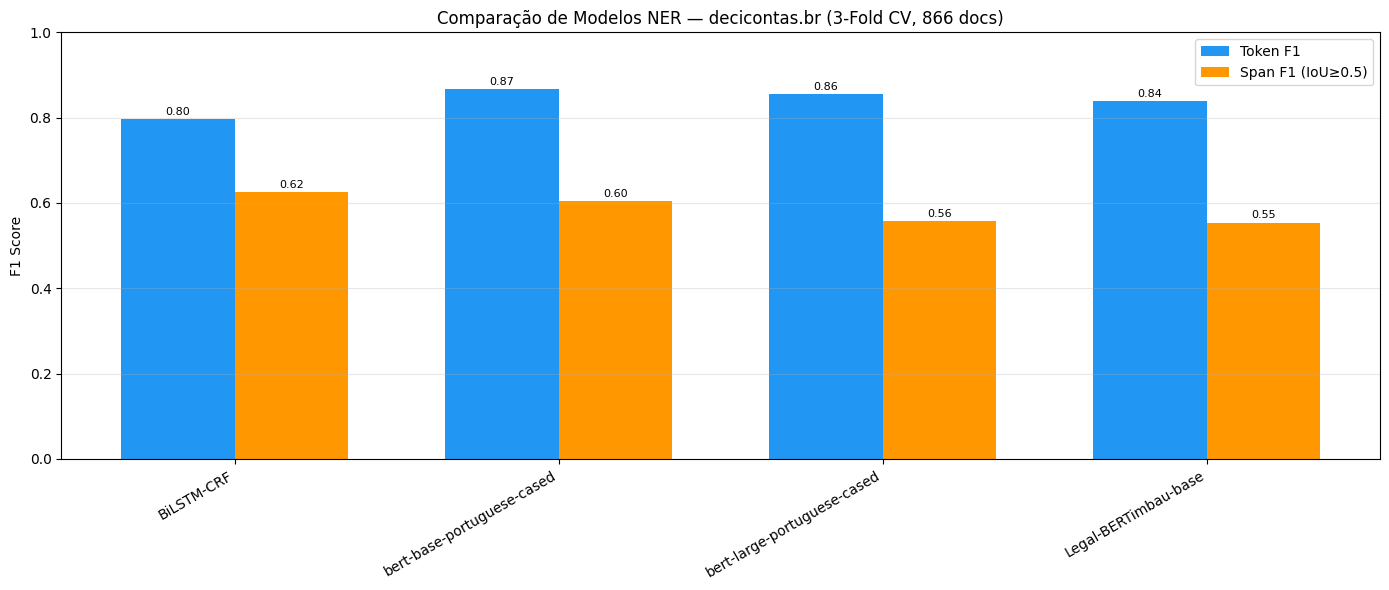

In [16]:
import matplotlib.pyplot as plt

models = [r['model'] for r in all_results]
token_f1s = [r['token_f1'] for r in all_results]
span_f1s = [r['span_f1'] for r in all_results]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, token_f1s, width, label='Token F1', color='#2196F3')
bars2 = ax.bar(x + width/2, span_f1s, width, label='Span F1 (IoU≥0.5)', color='#FF9800')

ax.set_ylabel('F1 Score')
ax.set_title(f'Comparação de Modelos NER — decicontas.br ({N_FOLDS}-Fold CV, {len(bio_data)} docs)')
ax.set_xticks(x)
ax.set_xticklabels([m.split('/')[-1] for m in models], rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('ner_comparison_kfold.png', dpi=150)
plt.show()

In [15]:
with open('ner_results_kfold.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

print('Resultados salvos em ner_results_kfold.json')
print(f'Checkpoints salvos em {CHECKPOINT_DIR}')

Resultados salvos em ner_results_kfold.json
Checkpoints salvos em /Users/eduardo/Dev/decicontas.br/dataset/results/checkpoints
